# Bloque III — Parte 2 (Entrega Final)

Clasificación, métricas y conclusiones.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay

%matplotlib inline

In [2]:
DATA_DIR = Path(".")
df = pd.read_csv(DATA_DIR / "clientes_clasificacion.csv")

X = df.drop(columns=["abandono"])
y = df["abandono"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,abandono
0,-1.411219,-0.514662,0.064036,0.586246,-0.458437,-0.322123,0
1,-1.075626,-0.401921,-0.018345,0.186611,1.047009,-0.195320,0
2,-2.084276,-1.661640,-2.440792,-2.384421,1.815373,-0.150552,0
3,-0.137564,-1.678457,-0.182502,0.021841,-0.748635,0.235910,0
4,-0.103918,-0.166164,-0.947579,-0.271781,-0.012278,-0.171772,0


## Modelo base: Regresión logística

In [3]:
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logit.fit(X_train, y_train)
pred_logit = logit.predict(X_test)

print(classification_report(y_test, pred_logit, digits=3))

              precision    recall  f1-score   support

           0      0.739     0.829     0.782        41
           1      0.588     0.455     0.513        22

    accuracy                          0.698        63
   macro avg      0.664     0.642     0.647        63
weighted avg      0.686     0.698     0.688        63



## Random Forest (modificado)

In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf, digits=3))

              precision    recall  f1-score   support

           0      0.932     1.000     0.965        41
           1      1.000     0.864     0.927        22

    accuracy                          0.952        63
   macro avg      0.966     0.932     0.946        63
weighted avg      0.956     0.952     0.951        63



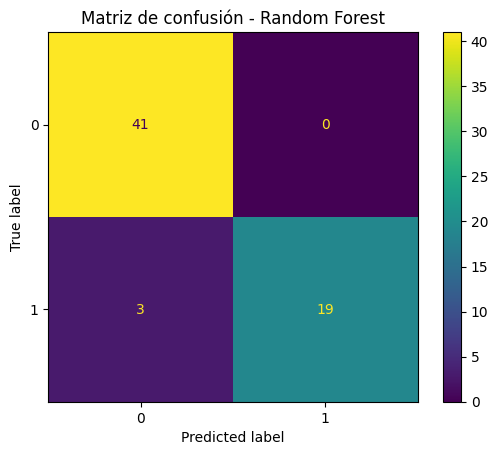

In [5]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Matriz de confusión - Random Forest")
plt.show()

## Curva ROC

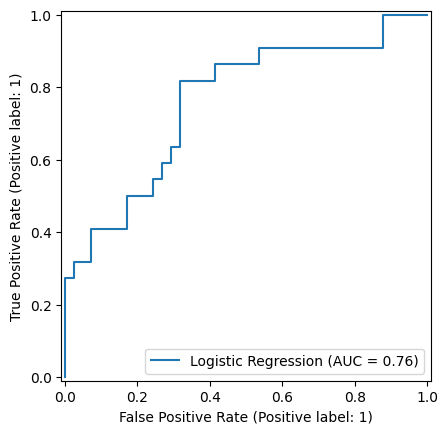

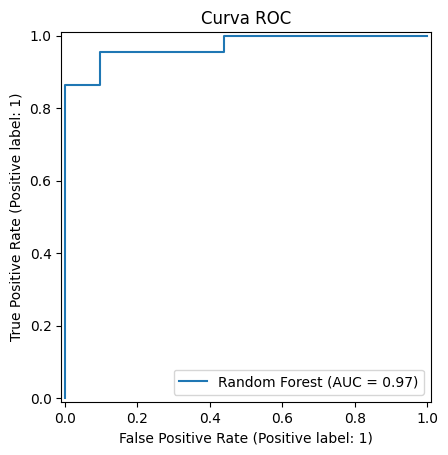

In [6]:
RocCurveDisplay.from_estimator(logit, X_test, y_test, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
plt.title("Curva ROC")
plt.show()

## Conclusiones

El modelo Random Forest presenta un mejor equilibrio entre precision y recall en comparación con la regresión logística.

La inclusión de class_weight="balanced" permite mejorar la detección de la clase minoritaria (abandono).

La matriz de confusión muestra que el modelo es capaz de identificar correctamente la mayoría de los casos, aunque aún existen errores.

Desde el punto de vista de negocio, es preferible priorizar el recall para detectar el mayor número posible de clientes en riesgo.

En este contexto, Random Forest es la mejor opción debido a su mayor capacidad predictiva y estabilidad.
